# BedMachine Antarctica

- Description: Bed topography and bathymetry map of Antarctica with ice thickness, surface elevation, and mask layers.
- Original data source: https://opensciencedata.esa.int/products/bedrock-topography-antarctica-bedmachine/collection
- Reference: https://nsidc.org/data/nsidc-0756/versions/3
- OSC entry: https://opensciencedata.esa.int/products/bedrock-topography-antarctica-bedmachine/collection
- License: CC0-1.0

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DATA_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.zarr/"

In [2]:
ds = xr.open_zarr(DATA_URL, chunks={})
ds

<xarray.Dataset> Size: 5GB
Dimensions:    (y: 13333, x: 13333)
Coordinates:
  * y          (y) int32 53kB 3333000 3332500 3332000 ... -3332500 -3333000
  * x          (x) int32 53kB -3333000 -3332500 -3332000 ... 3332500 3333000
Data variables:
    bed        (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dataid     (y, x) int8 178MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    errbed     (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    firn       (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    geoid      (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mapping    |S1 1B ...
    mask       (y, x) int8 178MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    rgi        (y, x) int8 178MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    source     (y, x) int8 178MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    surface    (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    thickness  (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/24)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    references:                  Morlighem, M. et al. (2020) Deep glacial tro...
    keywords:                    EARTH SCIENCE > CRYOSPHERE > GLACIERS/ICE SH...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015

Sample the grid before plotting. This keeps the notebook responsive while preserving the continent-scale pattern.

In [ ]:
coarsen_factor = 12
demo = ds[["bed", "thickness", "mask"]].coarsen(dim={"x": coarsen_factor, "y": coarsen_factor}, boundary="trim").max()
demo["grounded_thickness"] = demo["thickness"].where(demo["mask"] == 2)

demo

<xarray.Dataset> Size: 6MB
Dimensions:             (y: 666, x: 666)
Coordinates:
  * y                   (y) float64 5kB 3.328e+06 3.318e+06 ... -3.322e+06
  * x                   (x) float64 5kB -3.328e+06 -3.318e+06 ... 3.322e+06
Data variables:
    bed                 (y, x) float32 2MB dask.array<chunksize=(51, 51), meta=np.ndarray>
    thickness           (y, x) float32 2MB dask.array<chunksize=(51, 51), meta=np.ndarray>
    mask                (y, x) int8 444kB dask.array<chunksize=(51, 51), meta=np.ndarray>
    grounded_thickness  (y, x) float32 2MB dask.array<chunksize=(51, 51), meta=np.ndarray>
Attributes: (12/24)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    references:                  Morlighem, M. et al. (2020) Deep glacial tro...
    keywords:                    EARTH SCIENCE > CRYOSPHERE > GLACIERS/ICE SH...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015

Plot bed elevation and grounded ice thickness side by side.

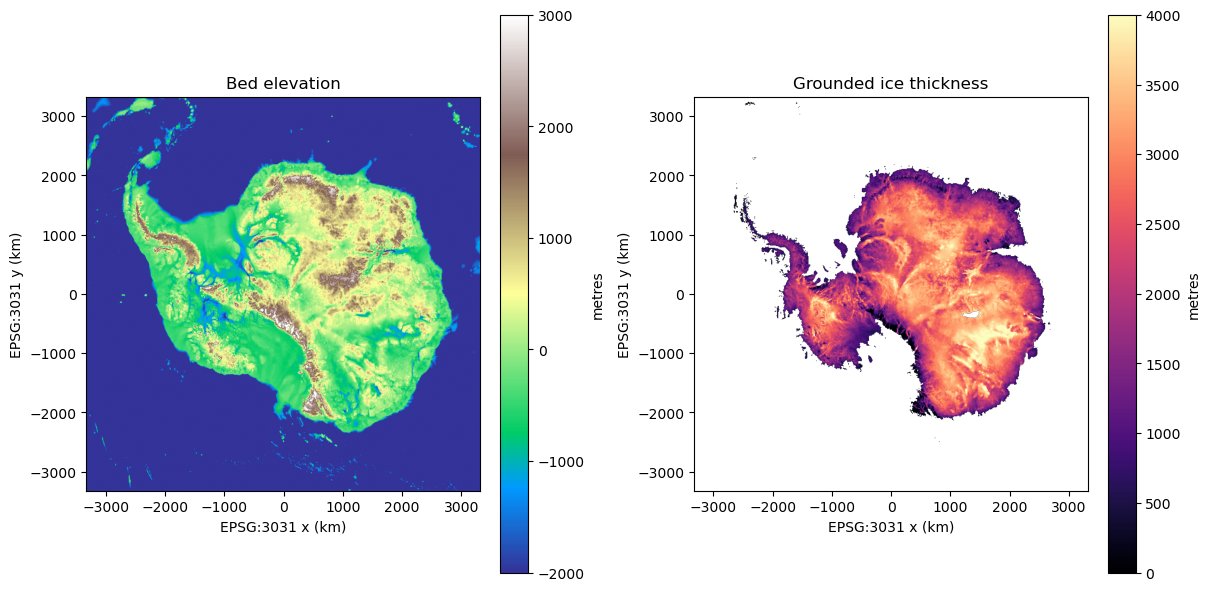

In [13]:
x_km = demo["x"].values / 1000
y_km = demo["y"].values / 1000
extent = [
    float(np.nanmin(x_km)),
    float(np.nanmax(x_km)),
    float(np.nanmin(y_km)),
    float(np.nanmax(y_km)),
]
origin = "upper" if y_km[0] > y_km[-1] else "lower"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), constrained_layout=True)

bed_image = axes[0].imshow(
    demo["bed"].values,
    extent=extent,
    origin=origin,
    cmap="terrain",
    vmin=-2000,
    vmax=3000,
)
axes[0].set_title("Bed elevation")
axes[0].set_xlabel("EPSG:3031 x (km)")
axes[0].set_ylabel("EPSG:3031 y (km)")
fig.colorbar(bed_image, ax=axes[0], label="metres")

thickness_image = axes[1].imshow(
    demo["grounded_thickness"].values,
    extent=extent,
    origin=origin,
    cmap="magma",
    vmin=0,
    vmax=4000,
)
axes[1].set_title("Grounded ice thickness")
axes[1].set_xlabel("EPSG:3031 x (km)")
axes[1].set_ylabel("EPSG:3031 y (km)")
fig.colorbar(thickness_image, ax=axes[1], label="metres")

for ax in axes:
    ax.set_aspect("equal")

plt.show()